# 第22章: 主成分分析

## 学習目標
- 主成分分析の定義と動機を理解する
- 固有値分解アプローチを適用できる
- 寄与率と累積寄与率を計算できる
- バイプロットを作成・解釈できる
- 主成分の解釈ができる

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy import linalg
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 22.1 主成分分析の定義と動機

### 定義
主成分分析 (PCA) は、多変量データの次元を削減しながら、データの分散を最大限保持する手法

### 目的
1. **次元削減**: 高次元データを低次元で表現
2. **可視化**: 2次元または3次元での視覚化
3. **多重共線性の除去**: 相関のある変数を無相関の主成分に変換
4. **ノイズ除去**: 主要な変動パターンの抽出

### 基本的なアイデア
データの分散が最大となる方向（第1主成分）を見つけ、それと直交する方向で次に分散が大きい方向（第2主成分）を見つける、という手順を繰り返す

主成分分析の基本概念

固有値: [4.47890714 0.43651209]
第1主成分の方向: [-0.79085918 -0.61199817]
第2主成分の方向: [ 0.61199817 -0.79085918]


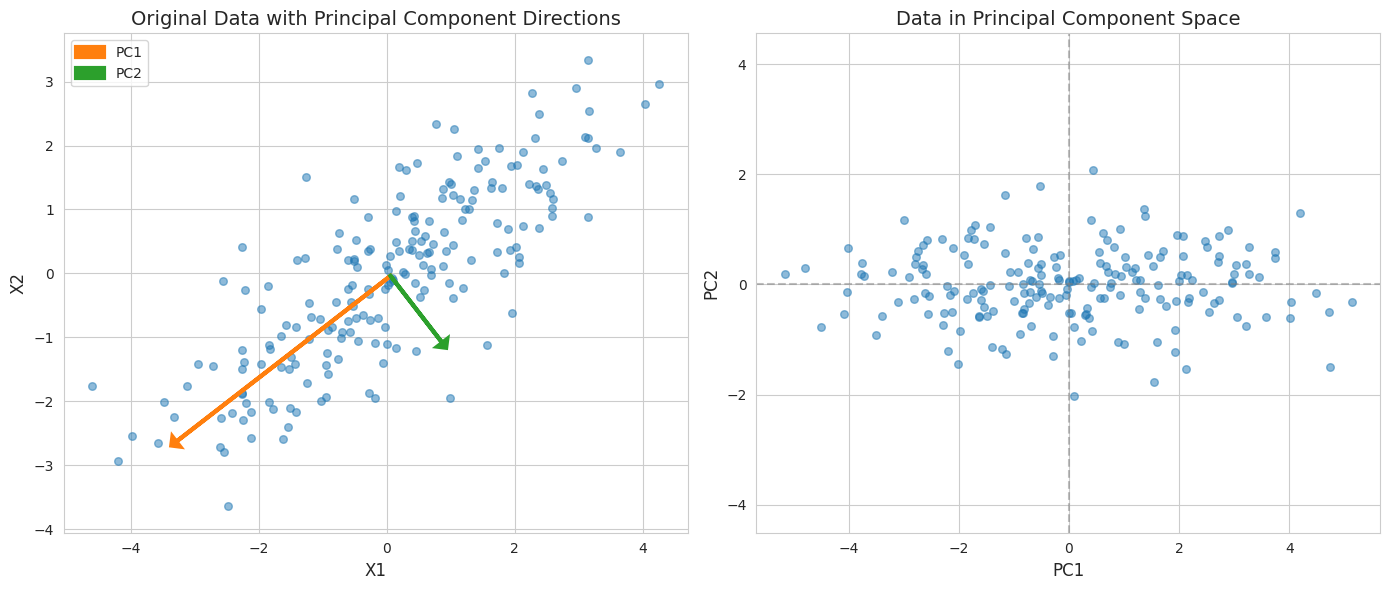


主成分空間での分散:
PC1の分散: 4.457
PC2の分散: 0.434


In [2]:
# PCAの基本概念の可視化
np.random.seed(123)

# Generate 2D correlated data
n = 200
mean = [0, 0]
cov = [[3, 2], [2, 2]]  # Correlated
X = np.random.multivariate_normal(mean, cov, n)

# Compute eigenvectors and eigenvalues
cov_matrix = np.cov(X.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort by eigenvalues (descending)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("主成分分析の基本概念")
print("="*50)
print(f"\n固有値: {eigenvalues}")
print(f"第1主成分の方向: {eigenvectors[:, 0]}")
print(f"第2主成分の方向: {eigenvectors[:, 1]}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original data with principal component directions
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.5, s=30)
origin = np.mean(X, axis=0)

# Draw principal component directions
for i in range(2):
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2
    axes[0].arrow(origin[0], origin[1], vec[0], vec[1], 
                  head_width=0.2, head_length=0.1, fc=f'C{i+1}', ec=f'C{i+1}',
                  linewidth=3, label=f'PC{i+1}')

axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('Original Data with Principal Component Directions', fontsize=14)
axes[0].legend()
axes[0].axis('equal')

# Transform to principal component space
X_centered = X - np.mean(X, axis=0)
X_pca = X_centered @ eigenvectors

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=30)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('Data in Principal Component Space', fontsize=14)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print(f"\n主成分空間での分散:")
print(f"PC1の分散: {np.var(X_pca[:, 0]):.3f}")
print(f"PC2の分散: {np.var(X_pca[:, 1]):.3f}")

## 22.2 固有値分解アプローチ

### 数学的定式化
データ行列 $\mathbf{X}$ (n×p) に対して:

1. **中心化**: $\tilde{\mathbf{X}} = \mathbf{X} - \bar{\mathbf{X}}$

2. **共分散行列**: $\mathbf{S} = \frac{1}{n-1}\tilde{\mathbf{X}}^T\tilde{\mathbf{X}}$

3. **固有値分解**: $\mathbf{S} = \mathbf{V}\mathbf{\Lambda}\mathbf{V}^T$

### 主成分
第 $k$ 主成分:
$$z_k = \mathbf{v}_k^T \tilde{\mathbf{x}} = v_{k1}x_1 + v_{k2}x_2 + \cdots + v_{kp}x_p$$

### 主成分の性質
- $\text{Var}(z_k) = \lambda_k$ (第k固有値)
- $\text{Cov}(z_j, z_k) = 0$ for $j \neq k$
- $\sum_{k=1}^{p} \lambda_k = \sum_{j=1}^{p} s_{jj}$ (全分散)

In [3]:
# 固有値分解によるPCAの実装
np.random.seed(456)

# Generate multivariate data
n = 300
p = 5

# Create correlated variables
mean = np.zeros(p)
# Create a covariance matrix with specific structure
cov = np.array([
    [4.0, 2.0, 1.5, 0.5, 0.0],
    [2.0, 3.0, 1.0, 0.3, 0.0],
    [1.5, 1.0, 2.0, 0.2, 0.0],
    [0.5, 0.3, 0.2, 1.0, 0.1],
    [0.0, 0.0, 0.0, 0.1, 0.5]
])

X = np.random.multivariate_normal(mean, cov, n)

print("固有値分解によるPCA")
print("="*60)
print(f"\nデータサイズ: n={n}, p={p}")

# Step 1: Center the data
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

# Step 2: Compute covariance matrix
S = np.cov(X_centered.T)

# Step 3: Eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eigh(S)

# Sort in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\n固有値:")
for i, val in enumerate(eigenvalues):
    print(f"  λ_{i+1} = {val:.4f}")

print("\n固有値の和:", np.sum(eigenvalues))
print("対角要素の和:", np.trace(S))

# Loadings matrix
print("\n因子負荷量 (Loadings):")
print(f"{'変数':>8}", end="")
for i in range(p):
    print(f"{'PC'+str(i+1):>10}", end="")
print()
for i in range(p):
    print(f"{'X'+str(i+1):>8}", end="")
    for j in range(p):
        print(f"{eigenvectors[i, j]:>10.3f}", end="")
    print()

固有値分解によるPCA

データサイズ: n=300, p=5

固有値:
  λ_1 = 6.4134
  λ_2 = 1.4032
  λ_3 = 1.1179
  λ_4 = 0.8196
  λ_5 = 0.5050

固有値の和: 10.259111126016315
対角要素の和: 10.259111126016316

因子負荷量 (Loadings):
      変数       PC1       PC2       PC3       PC4       PC5
      X1    -0.713    -0.573     0.268    -0.290     0.091
      X2    -0.586     0.794     0.155     0.004    -0.034
      X3    -0.364    -0.097    -0.887     0.268     0.001
      X4    -0.125    -0.174     0.336     0.879    -0.262
      X5     0.013     0.035     0.073     0.267     0.960


In [4]:
# Transform data to principal component space
Z = X_centered @ eigenvectors

# Verify properties
print("主成分の性質の確認")
print("="*50)

# Variance of each PC
print("\n各主成分の分散:")
for i in range(p):
    var_pc = np.var(Z[:, i], ddof=1)
    print(f"  Var(PC{i+1}) = {var_pc:.4f} (λ_{i+1} = {eigenvalues[i]:.4f})")

# Covariance between PCs
print("\n主成分間の相関行列:")
corr_pcs = np.corrcoef(Z.T)
print(np.round(corr_pcs, 3))

主成分の性質の確認

各主成分の分散:
  Var(PC1) = 6.4134 (λ_1 = 6.4134)
  Var(PC2) = 1.4032 (λ_2 = 1.4032)
  Var(PC3) = 1.1179 (λ_3 = 1.1179)
  Var(PC4) = 0.8196 (λ_4 = 0.8196)
  Var(PC5) = 0.5050 (λ_5 = 0.5050)

主成分間の相関行列:
[[ 1.  0.  0.  0.  0.]
 [ 0.  1. -0.  0. -0.]
 [ 0. -0.  1.  0. -0.]
 [ 0.  0.  0.  1. -0.]
 [ 0. -0. -0. -0.  1.]]


## 22.3 寄与率と累積寄与率

### 寄与率
第 $k$ 主成分の寄与率:
$$\text{Proportion}_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$$

### 累積寄与率
$$\text{Cumulative}_k = \frac{\sum_{j=1}^{k} \lambda_j}{\sum_{j=1}^{p} \lambda_j}$$

### 主成分の数の選択基準
1. **累積寄与率**: 70-80%以上
2. **カイザー基準**: $\lambda_k > 1$ (標準化データの場合)
3. **スクリープロット**: 肘の位置

寄与率と累積寄与率

   PC        固有値        寄与率        累積寄与率
----------------------------------------
    1     6.4134     62.51%       62.51%
    2     1.4032     13.68%       76.19%
    3     1.1179     10.90%       87.09%
    4     0.8196      7.99%       95.08%
    5     0.5050      4.92%      100.00%


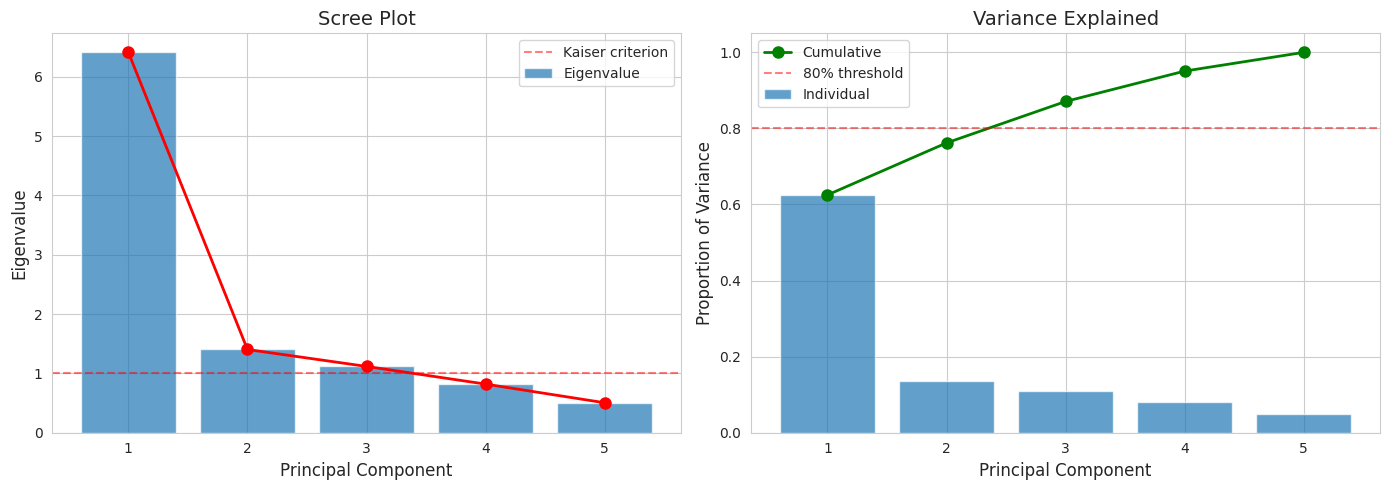

In [5]:
# 寄与率の計算と可視化
total_var = np.sum(eigenvalues)
proportion = eigenvalues / total_var
cumulative = np.cumsum(proportion)

print("寄与率と累積寄与率")
print("="*60)
print(f"\n{'PC':>5} {'固有値':>10} {'寄与率':>10} {'累積寄与率':>12}")
print("-"*40)
for i in range(p):
    print(f"{i+1:>5} {eigenvalues[i]:>10.4f} {proportion[i]:>10.2%} {cumulative[i]:>12.2%}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, p+1), eigenvalues, alpha=0.7, label='Eigenvalue')
axes[0].plot(range(1, p+1), eigenvalues, 'ro-', linewidth=2, markersize=8)
axes[0].axhline(1, color='red', linestyle='--', alpha=0.5, label='Kaiser criterion')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Eigenvalue', fontsize=12)
axes[0].set_title('Scree Plot', fontsize=14)
axes[0].legend()
axes[0].set_xticks(range(1, p+1))

# Cumulative proportion
axes[1].bar(range(1, p+1), proportion, alpha=0.7, label='Individual')
axes[1].plot(range(1, p+1), cumulative, 'go-', linewidth=2, markersize=8, label='Cumulative')
axes[1].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Proportion of Variance', fontsize=12)
axes[1].set_title('Variance Explained', fontsize=14)
axes[1].legend()
axes[1].set_xticks(range(1, p+1))

plt.tight_layout()
plt.show()

## 22.4 バイプロット

### 定義
バイプロットは、主成分空間において観測値と変数を同時に表示するグラフ

### 構成要素
1. **スコア**: 観測値の主成分得点（点で表示）
2. **ローディング**: 変数の主成分への寄与（矢印で表示）

### スケーリング
- **距離保存型**: スコアを $\sqrt{\lambda_k}$ でスケール
- **相関保存型**: ローディングを $\sqrt{\lambda_k}$ でスケール

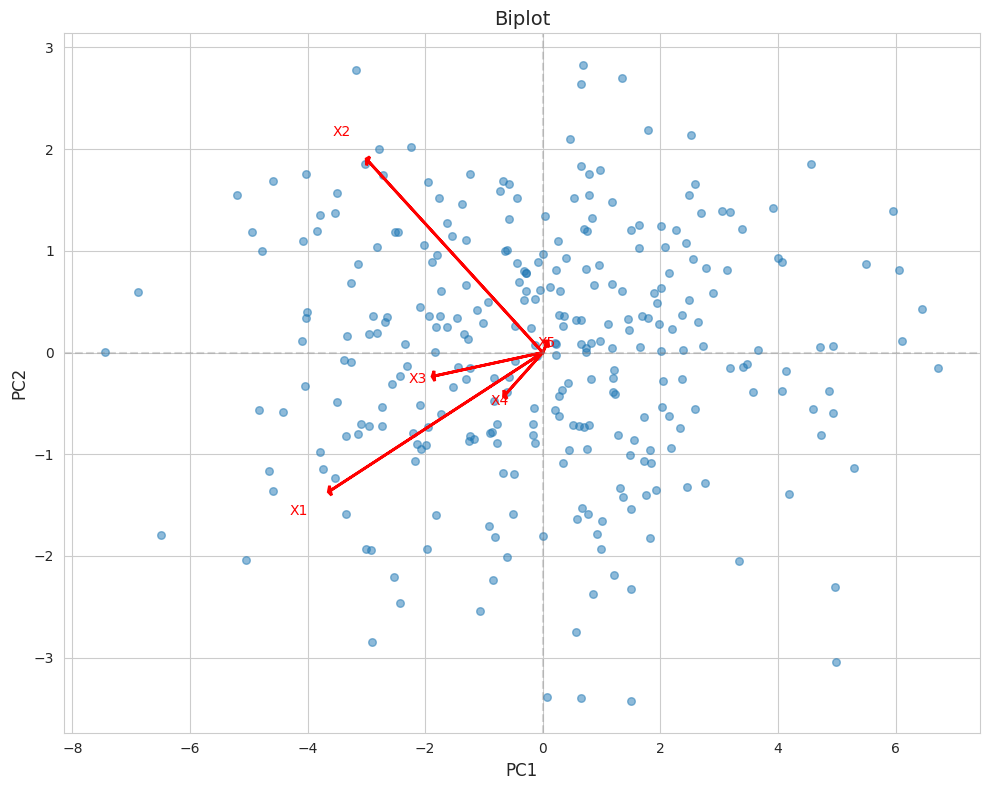

バイプロットの解釈

・近い位置の点は似た観測値
・矢印の長さは変数の分散の大きさ
・矢印間の角度は変数間の相関を表す
  - 0°に近い: 正の相関
  - 90°に近い: 無相関
  - 180°に近い: 負の相関


In [6]:
# バイプロットの作成
def biplot(scores, loadings, variable_names, scale=1.0, figsize=(10, 8)):
    """Create a biplot from PCA results."""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot scores
    ax.scatter(scores[:, 0], scores[:, 1], alpha=0.5, s=30)
    
    # Plot loadings as arrows
    for i, name in enumerate(variable_names):
        ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
                 head_width=0.05*scale, head_length=0.02*scale,
                 fc='red', ec='red', linewidth=2)
        ax.text(loadings[i, 0]*scale*1.15, loadings[i, 1]*scale*1.15,
                name, fontsize=10, ha='center', va='center', color='red')
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    ax.set_title('Biplot', fontsize=14)
    
    return fig, ax

# Create biplot
variable_names = [f'X{i+1}' for i in range(p)]
scores = Z[:, :2]
loadings = eigenvectors[:, :2]

# Scale loadings by sqrt of eigenvalues for correlation preservation
loadings_scaled = loadings * np.sqrt(eigenvalues[:2])

fig, ax = biplot(scores, loadings_scaled, variable_names, scale=2)
plt.tight_layout()
plt.show()

print("バイプロットの解釈")
print("="*50)
print("\n・近い位置の点は似た観測値")
print("・矢印の長さは変数の分散の大きさ")
print("・矢印間の角度は変数間の相関を表す")
print("  - 0°に近い: 正の相関")
print("  - 90°に近い: 無相関")
print("  - 180°に近い: 負の相関")

## 22.5 主成分の解釈

### 因子負荷量 (Factor Loadings)
第 $k$ 主成分と変数 $j$ の相関:
$$r_{jk} = v_{jk} \sqrt{\lambda_k} / s_j$$

標準化データの場合は $s_j = 1$ なので:
$$r_{jk} = v_{jk} \sqrt{\lambda_k}$$

### 解釈の手順
1. 負荷量の絶対値が大きい変数を特定
2. それらの変数に共通する概念を考える
3. 主成分に名前を付ける

In [7]:
# 実際のデータでPCAの解釈
np.random.seed(789)

# Generate interpretable data (e.g., academic performance)
n = 200

# Latent factors: general ability, verbal ability, math ability
general = np.random.normal(0, 1, n)
verbal = np.random.normal(0, 1, n)
math = np.random.normal(0, 1, n)

# Observed variables
reading = 0.8*general + 0.5*verbal + np.random.normal(0, 0.3, n)
writing = 0.7*general + 0.6*verbal + np.random.normal(0, 0.3, n)
vocabulary = 0.6*general + 0.7*verbal + np.random.normal(0, 0.3, n)
algebra = 0.7*general + 0.6*math + np.random.normal(0, 0.3, n)
geometry = 0.6*general + 0.7*math + np.random.normal(0, 0.3, n)
calculus = 0.5*general + 0.8*math + np.random.normal(0, 0.3, n)

# Create data matrix
X_academic = np.column_stack([reading, writing, vocabulary, algebra, geometry, calculus])
var_names = ['読解', '作文', '語彙', '代数', '幾何', '微積分']

# Standardize
scaler = StandardScaler()
X_std = scaler.fit_transform(X_academic)

# PCA
pca = PCA()
pca.fit(X_std)

print("学力データのPCA")
print("="*60)

# Loadings
loadings_academic = pca.components_.T * np.sqrt(pca.explained_variance_)

print("\n因子負荷量:")
print(f"{'変数':>10}", end="")
for i in range(3):
    print(f"{'PC'+str(i+1):>10}", end="")
print()
print("-"*40)
for i, name in enumerate(var_names):
    print(f"{name:>10}", end="")
    for j in range(3):
        val = loadings_academic[i, j]
        if abs(val) > 0.5:
            print(f"{val:>10.3f}*", end="")
        else:
            print(f"{val:>10.3f}", end="")
    print()

print("\n* は |loading| > 0.5 を示す")

学力データのPCA

因子負荷量:
        変数       PC1       PC2       PC3
----------------------------------------
        読解     0.875*     0.424    -0.155
        作文     0.860*     0.459     0.100
        語彙     0.808*     0.553*     0.081
        代数     0.877*    -0.405    -0.165
        幾何     0.832*    -0.500*    -0.041
       微積分     0.800*    -0.551*     0.205

* は |loading| > 0.5 を示す


/tmp/ipykernel_14735/2828991998.py:39: UserWarning: Glyph 35501 (\N{CJK UNIFIED IDEOGRAPH-8AAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14735/2828991998.py:39: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14735/2828991998.py:39: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14735/2828991998.py:39: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14735/2828991998.py:39: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14735/2828991998.py:39: UserWarning: Glyph 24409 (\N{CJK UNIFIED IDEOGRAPH-5F59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14735/2828991998.py:39: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAP

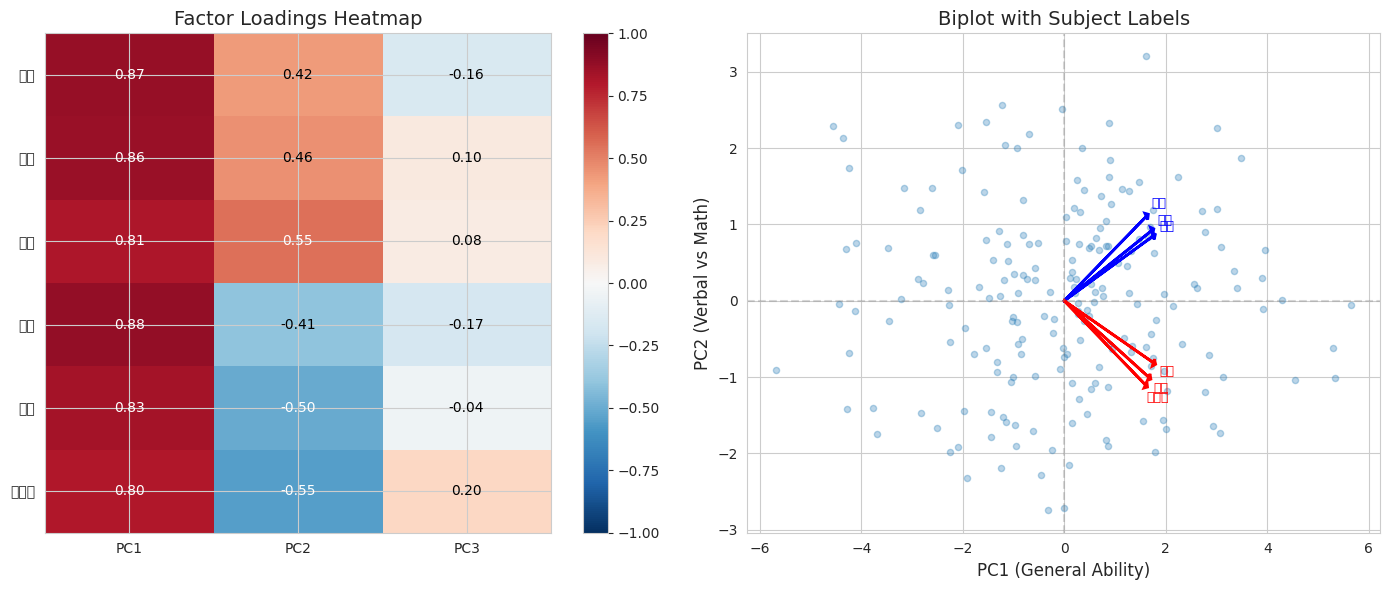


主成分の解釈:
PC1: 全科目に正の負荷 → 総合学力
PC2: 言語系が正、数学系が負 → 言語能力 vs 数学能力


In [8]:
# Visualize loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap of loadings
im = axes[0].imshow(loadings_academic[:, :3], cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0].set_yticks(range(len(var_names)))
axes[0].set_yticklabels(var_names)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['PC1', 'PC2', 'PC3'])
axes[0].set_title('Factor Loadings Heatmap', fontsize=14)
plt.colorbar(im, ax=axes[0])

# Add text annotations
for i in range(len(var_names)):
    for j in range(3):
        val = loadings_academic[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', color=color)

# Biplot for interpretation
scores_academic = pca.transform(X_std)[:, :2]
loadings_scaled_academic = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2]) * 2

axes[1].scatter(scores_academic[:, 0], scores_academic[:, 1], alpha=0.3, s=20)

colors = ['blue', 'blue', 'blue', 'red', 'red', 'red']
for i, name in enumerate(var_names):
    axes[1].arrow(0, 0, loadings_scaled_academic[i, 0], loadings_scaled_academic[i, 1],
                  head_width=0.1, head_length=0.05, fc=colors[i], ec=colors[i], linewidth=2)
    axes[1].text(loadings_scaled_academic[i, 0]*1.15, loadings_scaled_academic[i, 1]*1.15,
                 name, fontsize=9, ha='center', va='center', color=colors[i])

axes[1].axhline(0, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.3)
axes[1].set_xlabel('PC1 (General Ability)', fontsize=12)
axes[1].set_ylabel('PC2 (Verbal vs Math)', fontsize=12)
axes[1].set_title('Biplot with Subject Labels', fontsize=14)

plt.tight_layout()
plt.show()

print("\n主成分の解釈:")
print("="*50)
print("PC1: 全科目に正の負荷 → 総合学力")
print("PC2: 言語系が正、数学系が負 → 言語能力 vs 数学能力")

In [9]:
# Variance explained
print("\n寄与率:")
print("="*50)
for i in range(len(pca.explained_variance_ratio_)):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.1%} "
          f"(累積: {np.sum(pca.explained_variance_ratio_[:i+1]):.1%})")


寄与率:
PC1: 70.6% (累積: 70.6%)
PC2: 23.4% (累積: 94.1%)
PC3: 1.9% (累積: 95.9%)
PC4: 1.7% (累積: 97.6%)
PC5: 1.3% (累積: 98.9%)
PC6: 1.1% (累積: 100.0%)


## 22.6 相関行列 vs 共分散行列

### 共分散行列を使う場合
- 変数のスケールが同じ
- 分散の違いが重要

### 相関行列を使う場合（標準化）
- 変数のスケールが異なる
- 各変数を平等に扱いたい

In [10]:
# 標準化の効果
np.random.seed(111)

# Data with different scales
n = 200
X1 = np.random.normal(100, 30, n)  # Large scale
X2 = np.random.normal(5, 1, n)     # Small scale
X3 = X1 * 0.5 + np.random.normal(0, 10, n)  # Correlated with X1

X_scale = np.column_stack([X1, X2, X3])

print("標準化の効果")
print("="*60)

# PCA without standardization (covariance matrix)
pca_cov = PCA()
pca_cov.fit(X_scale)

# PCA with standardization (correlation matrix)
X_scale_std = StandardScaler().fit_transform(X_scale)
pca_corr = PCA()
pca_corr.fit(X_scale_std)

print("\n変数の統計量:")
print(f"{'変数':>8} {'平均':>10} {'標準偏差':>10}")
for i in range(3):
    print(f"X{i+1:>7} {np.mean(X_scale[:, i]):>10.2f} {np.std(X_scale[:, i]):>10.2f}")

print("\n共分散行列PCA (標準化なし):")
print(f"{'':>8} {'PC1':>10} {'PC2':>10} {'PC3':>10}")
for i in range(3):
    print(f"X{i+1:>7}", end="")
    for j in range(3):
        print(f"{pca_cov.components_[j, i]:>10.3f}", end="")
    print()
print(f"寄与率: {pca_cov.explained_variance_ratio_}")

print("\n相関行列PCA (標準化あり):")
print(f"{'':>8} {'PC1':>10} {'PC2':>10} {'PC3':>10}")
for i in range(3):
    print(f"X{i+1:>7}", end="")
    for j in range(3):
        print(f"{pca_corr.components_[j, i]:>10.3f}", end="")
    print()
print(f"寄与率: {pca_corr.explained_variance_ratio_}")

print("\n→ 標準化なしではX1とX3が支配的")
print("→ 標準化ありではX2も均等に寄与")

標準化の効果

変数の統計量:
      変数         平均       標準偏差
X      1     100.34      29.21
X      2       4.84       1.04
X      3      50.22      17.72

共分散行列PCA (標準化なし):
                PC1        PC2        PC3
X      1     0.877    -0.481     0.003
X      2     0.000     0.006     1.000
X      3     0.481     0.877    -0.006
寄与率: [9.28739253e-01 7.03407146e-02 9.20032316e-04]

相関行列PCA (標準化あり):
                PC1        PC2        PC3
X      1     0.707    -0.036    -0.707
X      2     0.024     0.999    -0.027
X      3     0.707     0.002     0.707
寄与率: [0.60576074 0.33337904 0.06086021]

→ 標準化なしではX1とX3が支配的
→ 標準化ありではX2も均等に寄与


## 22.7 練習問題

### 問題1
共分散行列
$$\mathbf{S} = \begin{pmatrix} 4 & 2 \\ 2 & 3 \end{pmatrix}$$
の固有値と固有ベクトルを求め、第1主成分の寄与率を計算せよ。

### 問題2
以下の条件を満たすデータに対してPCAを実行し、バイプロットを作成せよ:
- 5つの変数、100観測値
- 変数間に相関構造がある

### 問題3
主成分分析において、共分散行列と相関行列のどちらを使うべきか、その判断基準を説明せよ。

In [11]:
# 問題1の解答
print("問題1: 固有値分解")
print("="*50)

S = np.array([[4, 2], [2, 3]])

eigenvalues, eigenvectors = np.linalg.eigh(S)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\n共分散行列:")
print(S)

print(f"\n固有値:")
print(f"  λ_1 = {eigenvalues[0]:.4f}")
print(f"  λ_2 = {eigenvalues[1]:.4f}")

print(f"\n固有ベクトル:")
print(f"  v_1 = [{eigenvectors[0, 0]:.4f}, {eigenvectors[1, 0]:.4f}]")
print(f"  v_2 = [{eigenvectors[0, 1]:.4f}, {eigenvectors[1, 1]:.4f}]")

prop_1 = eigenvalues[0] / np.sum(eigenvalues)
print(f"\n第1主成分の寄与率: {prop_1:.2%}")

問題1: 固有値分解

共分散行列:
[[4 2]
 [2 3]]

固有値:
  λ_1 = 5.5616
  λ_2 = 1.4384

固有ベクトル:
  v_1 = [-0.7882, -0.6154]
  v_2 = [0.6154, -0.7882]

第1主成分の寄与率: 79.45%


問題2: PCAとバイプロット

寄与率:
PC1: 51.8%
PC2: 34.4%
PC3: 5.6%
PC4: 5.0%
PC5: 3.3%


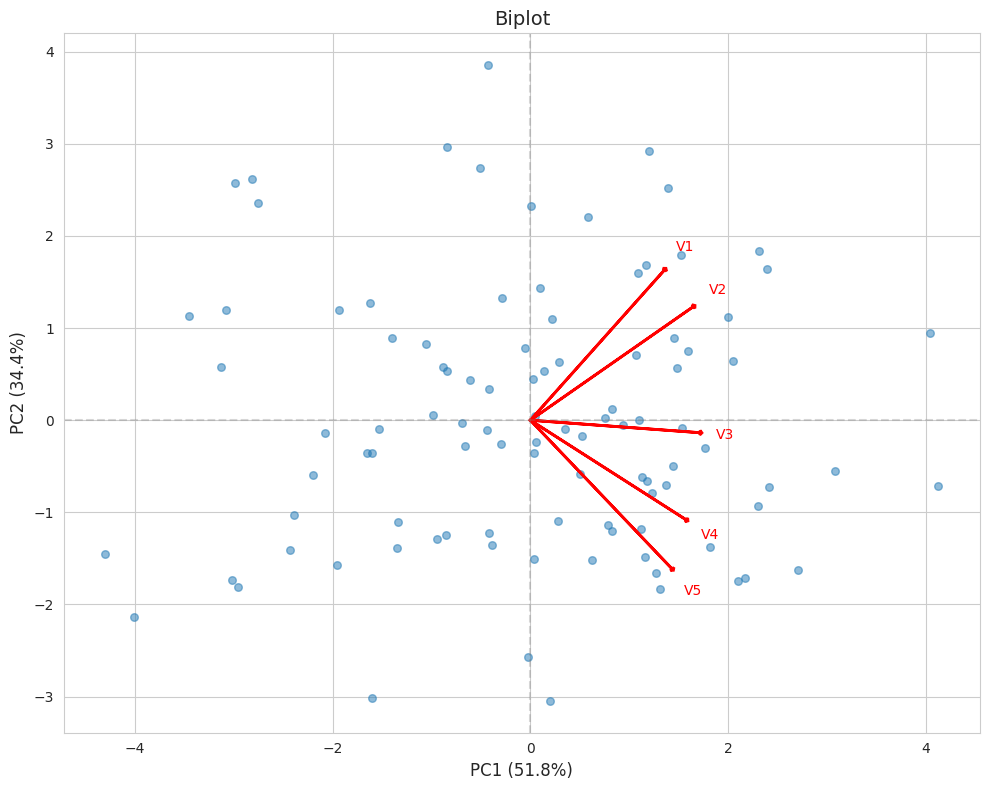

In [12]:
# 問題2の解答
print("問題2: PCAとバイプロット")
print("="*50)

np.random.seed(222)

# Generate data with correlation structure
n = 100
p = 5

# Create correlated data
mean = np.zeros(p)
cov = np.array([
    [1.0, 0.7, 0.3, 0.1, 0.0],
    [0.7, 1.0, 0.4, 0.2, 0.1],
    [0.3, 0.4, 1.0, 0.6, 0.5],
    [0.1, 0.2, 0.6, 1.0, 0.7],
    [0.0, 0.1, 0.5, 0.7, 1.0]
])

X_prob2 = np.random.multivariate_normal(mean, cov, n)

# PCA
pca_prob2 = PCA()
scores_prob2 = pca_prob2.fit_transform(X_prob2)

# Print results
print("\n寄与率:")
for i in range(p):
    print(f"PC{i+1}: {pca_prob2.explained_variance_ratio_[i]:.1%}")

# Biplot
var_names_prob2 = [f'V{i+1}' for i in range(p)]
loadings_prob2 = pca_prob2.components_[:2].T * np.sqrt(pca_prob2.explained_variance_[:2]) * 2

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(scores_prob2[:, 0], scores_prob2[:, 1], alpha=0.5, s=30)

for i, name in enumerate(var_names_prob2):
    ax.arrow(0, 0, loadings_prob2[i, 0], loadings_prob2[i, 1],
             head_width=0.05, head_length=0.02, fc='red', ec='red', linewidth=2)
    ax.text(loadings_prob2[i, 0]*1.15, loadings_prob2[i, 1]*1.15,
            name, fontsize=10, ha='center', va='center', color='red')

ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel(f'PC1 ({pca_prob2.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_prob2.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax.set_title('Biplot', fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
# 問題3の解答
print("問題3: 共分散行列 vs 相関行列")
print("="*60)

print("""
【共分散行列を使う場合】
1. 変数のスケール（単位）が同じ
2. 分散の違いそのものが重要な情報
3. 例: 同じ単位の金融資産リターン

【相関行列を使う場合（データの標準化）】
1. 変数のスケールが異なる
   - 例: 身長(cm)と体重(kg)
2. 各変数を平等に扱いたい
3. 分散の違いが本質的でない

【判断基準】
・まずデータの単位を確認
・単位が同じでも分散が著しく異なる場合は標準化を検討
・標準化するとすべての変数の分散が1になる
・一般的には標準化（相関行列）が推奨される
""")

問題3: 共分散行列 vs 相関行列

【共分散行列を使う場合】
1. 変数のスケール（単位）が同じ
2. 分散の違いそのものが重要な情報
3. 例: 同じ単位の金融資産リターン

【相関行列を使う場合（データの標準化）】
1. 変数のスケールが異なる
   - 例: 身長(cm)と体重(kg)
2. 各変数を平等に扱いたい
3. 分散の違いが本質的でない

【判断基準】
・まずデータの単位を確認
・単位が同じでも分散が著しく異なる場合は標準化を検討
・標準化するとすべての変数の分散が1になる
・一般的には標準化（相関行列）が推奨される



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---